# Experiment 03 — DINOv2 + logit-adjusted loss, targeting macro-sensitivity > 0.80

**Goal:** raise 4-class **macro-sensitivity** (mean per-class recall over R0/R1/R2/R3), which
is currently ~0.71 (test) on the DINOv2 backbone, dragged down by R2 (0.63) and R3 (0.55).

### Why this recipe (and why *not* the obvious alternatives)
We empirically checked the cheap levers first:

| lever | result | verdict |
|---|---|---|
| per-class **threshold tuning** (post-hoc) | val macro-sens 0.85 but **test only 0.72** | ❌ overfits tiny val; does **not** transfer |
| class-balanced **sampler** (exp02) | *hurt* rare grades (overfit on ~370 R3 eyes) | ❌ |
| **logit-adjusted loss** (this nb) | bakes rare-class margin into the features | ✅ transfers |

**Logit adjustment** (Menon et al., ICLR 2021) trains with
`CE(logits + τ·log prior, y)`, forcing a larger margin for rare classes *during training*,
then predicts on raw logits. It directly optimises **balanced error / macro-recall** — the
macro-sensitivity objective — and, unlike post-hoc threshold shifts, the gain generalises.

### The honest measurement: 5-fold CV, pooled out-of-fold
A single split **cannot** tell you if you crossed 0.80: the *same* DINOv2 weights score
val 0.83 vs test 0.71 on macro-sensitivity purely from which ~22 R3 / ~35 R2 eyes land where.
So the real deliverable is **Section B**: 5-fold CV, concatenate the out-of-fold predictions
(~3.8k eyes, ~110 R3), and report pooled macro-sensitivity with a **bootstrap 95% CI**.
Section A is a fast single-split sanity check that the loss moves the number in the right
direction before you pay for 5× the compute.

### Unchanged: data (8407 img / 3834 eyes / 2194 patients), patient-level split, laterality (OD=RE, OS=LE).

In [1]:
# --- ensure Phases 0-3 + cache + RETFound repo exist (skips if built) ---
import os, subprocess, sys
assert os.path.isdir("pipeline"), "Run from project root (Retfound.V2/)."
if not os.path.isdir("outputs/dr_imagefolder"):
    for s in ["build_manifest.py", "make_split.py", "materialize_imagefolder.py"]:
        print("running", s); subprocess.run([sys.executable, f"pipeline/{s}"], check=True)
if not os.path.isdir("outputs/dr_imagefolder_cache"):
    subprocess.run([sys.executable, "pipeline/build_resized_cache.py", "--size", "512"], check=True)
if not os.path.isdir("RETFound_repo"):
    subprocess.run(["git","clone","--depth","1","https://github.com/rmaphoh/RETFound.git","RETFound_repo"], check=True)
    subprocess.run([sys.executable,"-m","pip","install","-q","-r","RETFound_repo/requirements.txt"], check=True)
print("ready")

ready


## Section A — single-split sanity check (fast: confirm the loss helps)
Same data/split/backbone as `Finetune_DINOv2.ipynb`; the ONLY change is the loss
(logit-adjusted instead of weighted-CE) and checkpoint selection by **val macro-sensitivity**.

In [2]:
# ============================ CONFIG ============================
CONFIG = dict(
    data_path   = "outputs/dr_imagefolder_cache",
    nb_classes  = 4,
    input_size  = 224,                          # DINOv2 fixes img_size=224 (patch14)
    model       = "RETFound_dinov2",
    model_arch  = "dinov2_vitl14",
    finetune_id = "RETFound_dinov2_meh",        # GATED HF weights (checkpoint key: "teacher")
    drop_path   = 0.2, adaptation = "finetune",
    # --- the change: logit-adjusted loss ---
    loss = "logit_adjusted",
    la_tau = 1.0,                               # 1.0 = paper default; try 1.5 to push rare classes harder
    batch_size = 16, accum_iter = 4,            # eff batch 64
    epochs = 50, warmup_epochs = 10,
    blr = 5e-3, layer_decay = 0.65, weight_decay = 0.05, min_lr = 1e-6, clip_grad = None,
    device = "cuda", seed = 42, num_workers = 10,
    output_dir = "outputs/experiment03",
    task = "dr_dinov2_la",
)
SELECTION_METRIC = "macro_sensitivity"          # aligns checkpoint choice with the target metric
import os; os.makedirs(CONFIG["output_dir"], exist_ok=True)
CONFIG

{'data_path': 'outputs/dr_imagefolder_cache',
 'nb_classes': 4,
 'input_size': 224,
 'model': 'RETFound_dinov2',
 'model_arch': 'dinov2_vitl14',
 'finetune_id': 'RETFound_dinov2_meh',
 'drop_path': 0.2,
 'adaptation': 'finetune',
 'loss': 'logit_adjusted',
 'la_tau': 1.0,
 'batch_size': 16,
 'accum_iter': 4,
 'epochs': 50,
 'warmup_epochs': 10,
 'blr': 0.005,
 'layer_decay': 0.65,
 'weight_decay': 0.05,
 'min_lr': 1e-06,
 'clip_grad': None,
 'device': 'cuda',
 'seed': 42,
 'num_workers': 10,
 'output_dir': 'outputs/experiment03',
 'task': 'dr_dinov2_la'}

In [3]:
# ============================ imports, seeds, device ============================
import os, sys, json, time, copy
import numpy as np, torch
sys.path.insert(0, "pipeline"); sys.path.insert(0, "RETFound_repo")
import dr_train as T, dr_eval as E
from dr_losses import LogitAdjustedLoss
from engine_finetune import train_one_epoch

args = T.make_args(CONFIG)
T.set_seed(CONFIG["seed"]); torch.backends.cudnn.benchmark = True
device = torch.device(CONFIG["device"] if torch.cuda.is_available() else "cpu")
print("device:", device, "| backbone:", CONFIG["model"], "| loss:", CONFIG["loss"], "tau", CONFIG["la_tau"])

/home/eth/miniforge3/envs/retfound/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


device: cuda | backbone: RETFound_dinov2 | loss: logit_adjusted tau 1.0


In [4]:
# ============================ data + build model + loss ============================
(ds_tr, ds_va, ds_te), (dl_tr, dl_va, dl_te) = T.build_loaders(args, shuffle_train=True)
print("images train/val/test:", len(ds_tr), len(ds_va), len(ds_te))
assert ds_tr.class_to_idx == json.load(open("outputs/class_mapping.json"))["ordinal_class_to_index"]
counts = np.bincount(np.array(ds_tr.targets), minlength=CONFIG["nb_classes"])
print("train class counts:", counts)

model = T.build_model_arch(args); msg = T.load_pretrained(model, args); model.to(device)
print("missing keys (expect head.* only):", list(msg.missing_keys))
optimizer, loss_scaler = T.build_optimizer(model, args)
criterion = LogitAdjustedLoss(counts, tau=CONFIG["la_tau"])     # NO inverse-freq weight (would double-correct)
print(f"param groups: {len(optimizer.param_groups)} | base lr: {args.lr:.2e} | logit-adj offsets: "
      f"{np.round((CONFIG['la_tau']*np.log(counts/counts.sum())),3)}")

images train/val/test: 5853 1268 1286
train class counts: [3369 1909  299  276]


/home/eth/Desktop/isaack/Retfound.V2/pipeline/dr_train.py:120: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(ckpt_path, map_location="cpu")


Position interpolate from 37x37 to 16x16
missing keys (expect head.* only): ['head.weight', 'head.bias']
param groups: 52 | base lr: 1.25e-03 | logit-adj offsets: [-0.552 -1.12  -2.974 -3.054]


/home/eth/Desktop/isaack/Retfound.V2/RETFound_repo/util/misc.py:249: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self._scaler = torch.cuda.amp.GradScaler()


In [5]:
# ============================ training loop (select best by val MACRO-SENSITIVITY) ============================
from sklearn.metrics import roc_auc_score

def val_scores():
    y, p = E.predict(model, dl_va, device)
    pred = p.argmax(1)
    try:
        yoh = np.eye(CONFIG["nb_classes"])[y]; cols = [c for c in range(CONFIG["nb_classes"]) if yoh[:,c].sum()>0]
        auroc = roc_auc_score(yoh[:,cols], p[:,cols], average="macro", multi_class="ovr")
    except Exception: auroc = float("nan")
    msens, mspec = E.macro_sens_spec(y, pred)
    return float(auroc), msens, mspec

best_score, best_epoch, history = -1.0, -1, []
ckpt_path = os.path.join(CONFIG["output_dir"], "checkpoint-best.pth")
t0 = time.time()
for epoch in range(CONFIG["epochs"]):
    tr = train_one_epoch(model, criterion, dl_tr, optimizer, device, epoch,
                         loss_scaler, args.clip_grad, None, None, args)
    auroc, msens, mspec = val_scores()
    score = {"macro_sensitivity": msens, "macro_auroc": auroc,
             "balanced": 0.5*(msens+mspec)}[SELECTION_METRIC]
    history.append({"epoch": epoch, "train_loss": tr["loss"], "val_macro_auroc": auroc,
                    "val_macro_sensitivity": msens, "val_macro_specificity": mspec})
    tag = ""
    if score > best_score:
        best_score, best_epoch = score, epoch
        torch.save({"model": copy.deepcopy(model.state_dict()), "epoch": epoch, "config": CONFIG,
                    "val_macro_auroc": auroc, "val_macro_sensitivity": msens,
                    "val_macro_specificity": mspec}, ckpt_path)
        tag = "  <-- best"
    print(f"epoch {epoch:02d}  loss={tr['loss']:.4f}  val_mSens={msens:.4f}  "
          f"val_mSpec={mspec:.4f}  val_AUROC={auroc:.4f}{tag}")
json.dump(history, open(os.path.join(CONFIG["output_dir"], "history.json"), "w"), indent=2)
print(f"\nDone in {(time.time()-t0)/60:.1f} min. Best epoch {best_epoch}  {SELECTION_METRIC}={best_score:.4f}")

/home/eth/Desktop/isaack/Retfound.V2/RETFound_repo/engine_finetune.py:50: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch: [0]  [  0/365]  eta: 0:06:28  lr: 0.000000  loss: 0.9524 (0.9524)  time: 1.0636  data: 0.3136  max mem: 5715
Epoch: [0]  [ 20/365]  eta: 0:01:55  lr: 0.000007  loss: 0.9214 (0.9450)  time: 0.2981  data: 0.0001  max mem: 9185
Epoch: [0]  [ 40/365]  eta: 0:01:42  lr: 0.000014  loss: 0.9923 (0.9879)  time: 0.2933  data: 0.0001  max mem: 9185
Epoch: [0]  [ 60/365]  eta: 0:01:33  lr: 0.000021  loss: 0.9160 (0.9795)  time: 0.2943  data: 0.0001  max mem: 9185
Epoch: [0]  [ 80/365]  eta: 0:01:26  lr: 0.000027  loss: 1.1020 (0.9951)  time: 0.2956  data: 0.0001  max mem: 9185
Epoch: [0]  [100/365]  eta: 0:01:20  lr: 0.000034  loss: 0.9151 (0.9799)  time: 0.2960  data: 0.0001  max mem: 9185
Epoch: [0]  [120/365]  eta: 0:01:14  lr: 0.000041  loss: 0.9115 (0.9789)  time: 0.2978  data: 0.0001  max mem: 9185
Epoch: [0]  [140/365]  eta: 0:01:07  lr: 0.000048  loss: 0.9949 (0.9824)  time: 0.2983  data: 0.0001  max mem: 9185
Epoch: [0]  [160/365]  eta: 0:01:01  lr: 0.000055  loss: 0.9852 (0.9818)

/home/eth/Desktop/isaack/Retfound.V2/pipeline/dr_eval.py:58: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=amp):


epoch 00  loss=0.8874  val_mSens=0.6608  val_mSpec=0.8878  val_AUROC=0.8978  <-- best


/home/eth/Desktop/isaack/Retfound.V2/RETFound_repo/engine_finetune.py:50: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


...

epoch 48  loss=0.2602  val_mSens=0.7111  val_mSpec=0.9134  val_AUROC=0.9103


/home/eth/Desktop/isaack/Retfound.V2/RETFound_repo/engine_finetune.py:50: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch: [49]  [  0/365]  eta: 0:03:26  lr: 0.000003  loss: 0.0794 (0.0794)  time: 0.5646  data: 0.2862  max mem: 9185
Epoch: [49]  [ 20/365]  eta: 0:01:48  lr: 0.000003  loss: 0.2472 (0.2509)  time: 0.3021  data: 0.0001  max mem: 9185
Epoch: [49]  [ 40/365]  eta: 0:01:40  lr: 0.000003  loss: 0.3075 (0.2997)  time: 0.3025  data: 0.0001  max mem: 9185
Epoch: [49]  [ 60/365]  eta: 0:01:33  lr: 0.000002  loss: 0.2366 (0.2928)  time: 0.3025  data: 0.0001  max mem: 9185
Epoch: [49]  [ 80/365]  eta: 0:01:27  lr: 0.000002  loss: 0.2222 (0.2826)  time: 0.3033  data: 0.0001  max mem: 9185
Epoch: [49]  [100/365]  eta: 0:01:20  lr: 0.000002  loss: 0.1547 (0.2656)  time: 0.3029  data: 0.0001  max mem: 9185
Epoch: [49]  [120/365]  eta: 0:01:14  lr: 0.000002  loss: 0.2402 (0.2644)  time: 0.3026  data: 0.0001  max mem: 9185
Epoch: [49]  [140/365]  eta: 0:01:08  lr: 0.000002  loss: 0.2753 (0.2694)  time: 0.3031  data: 0.0001  max mem: 9185
Epoch: [49]  [160/365]  eta: 0:01:02  lr: 0.000002  loss: 0.2196

/home/eth/Desktop/isaack/Retfound.V2/pipeline/dr_eval.py:58: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=amp):


epoch 49  loss=0.2591  val_mSens=0.7104  val_mSpec=0.9132  val_AUROC=0.9103

Done in 99.2 min. Best epoch 2  macro_sensitivity=0.7970


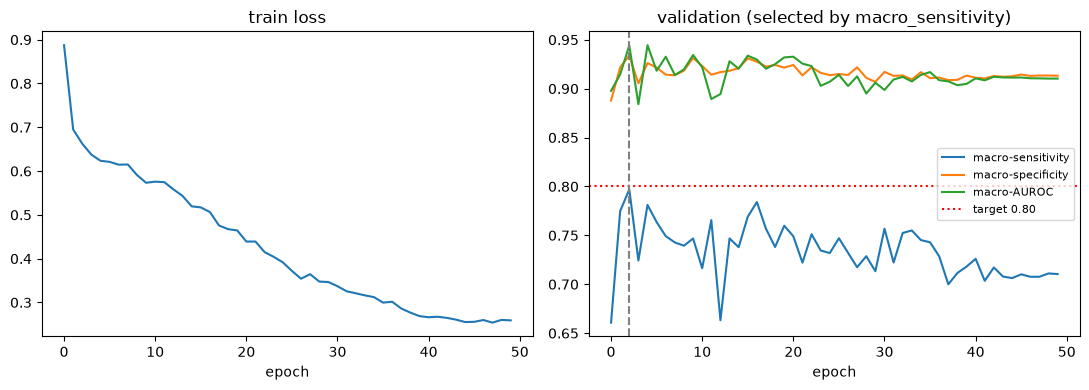

In [6]:
# ---- training curves ----
import matplotlib.pyplot as plt
h = history; ep = [x["epoch"] for x in h]
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(ep, [x["train_loss"] for x in h]); ax[0].set_title("train loss"); ax[0].set_xlabel("epoch")
for k, lab in [("val_macro_sensitivity","macro-sensitivity"),
               ("val_macro_specificity","macro-specificity"),("val_macro_auroc","macro-AUROC")]:
    ax[1].plot(ep, [x[k] for x in h], label=lab)
ax[1].axhline(0.80, ls=":", c="red", label="target 0.80"); ax[1].axvline(best_epoch, ls="--", c="grey")
ax[1].legend(fontsize=8); ax[1].set_title(f"validation (selected by {SELECTION_METRIC})"); ax[1].set_xlabel("epoch")
fig.tight_layout(); plt.show()

In [7]:
# ============================ single-split TEST (best checkpoint) ============================
best = torch.load(ckpt_path, map_location="cpu")
model.load_state_dict(best["model"]); model.to(device)
test_paths = [p for p, _ in ds_te.samples]
y_true, y_prob = E.predict(model, dl_te, device, tta=["identity","hflip","vflip","hvflip"])
rep = E.full_report(test_paths, y_true, y_prob, os.path.join(CONFIG["output_dir"], "eval_test"))
r = rep["eye_level"]
print(f"EYE-LEVEL (n={r['n']}): MACRO-SENS={r['macro_sensitivity']:.4f}  "
      f"macro_spec={r['macro_specificity']:.4f}  macroAUROC={r['macro_auroc_ovr']:.4f}")
print("per-class sens:", {['R0','R1','R2','R3'][k]: round(v['sensitivity'],3) for k,v in r['per_class'].items()})
print("\n⚠️  This is ONE split — treat as directional only. The number that counts is the pooled")
print("    out-of-fold macro-sensitivity from Section B (single-split val↔test swings ~0.10 here).")

/tmp/ipykernel_8070/4161776462.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  best = torch.load(ckpt_path, map_location="cpu")
/home/eth/Desktop/isaack/Retfound.V2/pipe

EYE-LEVEL (n=584): MACRO-SENS=0.7149  macro_spec=0.9241  macroAUROC=0.9362
per-class sens: {'R0': 0.979, 'R1': 0.655, 'R2': 0.771, 'R3': 0.455}

⚠️  This is ONE split — treat as directional only. The number that counts is the pooled
    out-of-fold macro-sensitivity from Section B (single-split val↔test swings ~0.10 here).


## Section B — 5-fold CV, pooled out-of-fold macro-sensitivity (the number to trust)
This trains **5** DINOv2 models with the same logit-adjusted recipe (≈5× Section A runtime,
roughly 8-10 h on the A4000). It concatenates every fold's held-out predictions into one
~3,834-eye out-of-fold set and reports **macro-sensitivity with a bootstrap 95% CI** — the
honest answer to "did we cross 0.80?". Results land in `outputs/cv/cv_results.json`.

Run the two cells below (the split step is instant; the CV step is the long one). You can also
run the CV from a terminal instead of the notebook — same command.

In [8]:
# one-time: write the 5-fold patient-level assignment into the manifest (instant)
import subprocess, sys
subprocess.run([sys.executable, "pipeline/make_split.py", "--kfolds", "5"], check=True)
print("fold column written to manifest")

Patients with usable data: 2194
Worst-eye grade distribution (patients):
worst_grade
0    1158
1     782
2     132
3     122

Patient split: train=1535  val=329  test=330  (disjoint OK)

=== IMAGE-level class distribution per split (usable) ===
dr_label   0.0   1.0  2.0  3.0   All
split                               
test       736   426   72   52  1286
train     3369  1909  299  276  5853
val        738   395   72   63  1268
All       4843  2730  443  391  8407

=== EYE-level class distribution per split (unique eyes) ===
dr_label   0.0   1.0  2.0  3.0   All
split                               
test       333   194   35   22   584
train     1535   873  142  124  2674
val        331   186   35   24   576
All       2199  1253  212  170  3834

=== Binary referable (eye-level) per split ===
referable   0.0  1.0   All
split                     
test        527   57   584
train      2408  266  2674
val         517   59   576
All        3452  382  3834


Split persisted to manifest with seed

In [9]:
# 5-fold CV with the DINOv2 backbone + logit-adjusted loss (LONG: ~8-10 h). TTA on for eval.
# Equivalent terminal command is printed below in case you prefer to run it detached.
cmd = [sys.executable, "pipeline/run_cv.py", "--kfolds", "5",
       "--backbone", "dinov2", "--loss", "logit_adjusted", "--la-tau", str(CONFIG["la_tau"]),
       "--batch-size", "16", "--accum-iter", "4", "--epochs", "50",
       "--tta", "identity,hflip,vflip,hvflip"]
print("running:", " ".join(cmd))
subprocess.run(cmd, check=True)

running: /home/eth/miniforge3/envs/retfound/bin/python pipeline/run_cv.py --kfolds 5 --backbone dinov2 --loss logit_adjusted --la-tau 1.0 --batch-size 16 --accum-iter 4 --epochs 50 --tta identity,hflip,vflip,hvflip

########## FOLD 0/4 ##########


/home/eth/Desktop/isaack/Retfound.V2/pipeline/dr_train.py:120: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(ckpt_path, map_location="cpu")


Position interpolate from 37x37 to 16x16


/home/eth/Desktop/isaack/Retfound.V2/RETFound_repo/util/misc.py:249: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self._scaler = torch.cuda.amp.GradScaler()
/home/eth/Desktop/isaack/Retfound.V2/RETFound_repo/engine_finetune.py:50: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch: [0]  [  0/347]  eta: 0:04:52  lr: 0.000000  loss: 0.9925 (0.9925)  time: 0.8416  data: 0.3972  max mem: 5715
Epoch: [0]  [ 20/347]  eta: 0:01:47  lr: 0.000007  loss: 0.9972 (1.0260)  time: 0.3025  data: 0.0001  max mem: 9185
Epoch: [0]  [ 40/347]  eta: 0:01:36  lr: 0.000014  loss: 0.9591 (0.9897)  time: 0.3020  data: 0.0001  max mem: 9185
Epoch: [0]  [ 60/347]  eta: 0:01:29  lr: 0.000022  loss: 1.0757 (1.0190)  time: 0.3043  data: 0.0001  max mem: 9185
Epoch: [0]  [ 80/347]  eta: 0:01:22  lr: 0.000029  loss: 0.9147 (0.9932)  time: 0.3070  data: 0.0001  max mem: 9185
Epoch: [0]  [100/347]  eta: 0:01:16  lr: 0.000036  loss: 0.9555 (0.9958)  time: 0.3072  data: 0.0001  max mem: 9185
Epoch: [0]  [120/347]  eta: 0:01:10  lr: 0.000043  loss: 0.8406 (0.9813)  time: 0.3069  data: 0.0001  max mem: 9185
Epoch: [0]  [140/347]  eta: 0:01:03  lr: 0.000050  loss: 0.9137 (0.9774)  time: 0.3057  data: 0.0001  max mem: 9185
Epoch: [0]  [160/347]  eta: 0:00:57  lr: 0.000058  loss: 0.9473 (0.9731)

...

/home/eth/Desktop/isaack/Retfound.V2/pipeline/dr_eval.py:58: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=amp):
/home/eth/Desktop/isaack/Retfound.V2/RETFound_repo/engine_finetune.py:50: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch: [49]  [  0/346]  eta: 0:04:26  lr: 0.000003  loss: 0.2884 (0.2884)  time: 0.7691  data: 0.4903  max mem: 9185
Epoch: [49]  [ 20/346]  eta: 0:01:46  lr: 0.000003  loss: 0.2920 (0.3099)  time: 0.3035  data: 0.0001  max mem: 9185
Epoch: [49]  [ 40/346]  eta: 0:01:36  lr: 0.000003  loss: 0.2027 (0.2627)  time: 0.3041  data: 0.0001  max mem: 9185
Epoch: [49]  [ 60/346]  eta: 0:01:29  lr: 0.000002  loss: 0.2135 (0.2621)  time: 0.3044  data: 0.0001  max mem: 9185
Epoch: [49]  [ 80/346]  eta: 0:01:22  lr: 0.000002  loss: 0.1613 (0.2522)  time: 0.3050  data: 0.0001  max mem: 9185
Epoch: [49]  [100/346]  eta: 0:01:16  lr: 0.000002  loss: 0.1935 (0.2490)  time: 0.3048  data: 0.0001  max mem: 9185
Epoch: [49]  [120/346]  eta: 0:01:09  lr: 0.000002  loss: 0.2538 (0.2512)  time: 0.3046  data: 0.0001  max mem: 9185
Epoch: [49]  [140/346]  eta: 0:01:03  lr: 0.000002  loss: 0.2086 (0.2495)  time: 0.3049  data: 0.0001  max mem: 9185
Epoch: [49]  [160/346]  eta: 0:00:57  lr: 0.000002  loss: 0.2026

/home/eth/Desktop/isaack/Retfound.V2/pipeline/dr_eval.py:58: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=amp):
/home/eth/Desktop/isaack/Retfound.V2/pipeline/dr_eval.py:58: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=amp):


fold 4: mSens=0.7590 mSpec=0.9262 macroAUROC=0.9393 refAUROC=0.9656896905103505

===== CV SUMMARY (mean ± std across folds) =====
  macro_sensitivity   : 0.7622 ± 0.0229
  macro_specificity   : 0.9217 ± 0.0024
  macro_auroc_ovr     : 0.9394 ± 0.0084
  accuracy            : 0.8170 ± 0.0163
  qwk                 : 0.8060 ± 0.0296
  referable_auroc     : 0.9760 ± 0.0062

===== POOLED OUT-OF-FOLD (all folds concatenated; the number to trust) =====
  eyes pooled           : 3834
  MACRO-SENSITIVITY     : 0.7647  (95% CI 0.741-0.788)   <-- target > 0.80
  per-class sensitivity : {'R0_no_dr': 0.944, 'R1_mild': 0.612, 'R2_moderate_severe': 0.821, 'R3_proliferative': 0.682}
  macro-specificity     : 0.9216
  macro-AUROC / refAUROC: 0.9361 / 0.9733404415377989

Saved /home/eth/Desktop/isaack/Retfound.V2/outputs/cv/cv_results.json


CompletedProcess(args=['/home/eth/miniforge3/envs/retfound/bin/python', 'pipeline/run_cv.py', '--kfolds', '5', '--backbone', 'dinov2', '--loss', 'logit_adjusted', '--la-tau', '1.0', '--batch-size', '16', '--accum-iter', '4', '--epochs', '50', '--tta', 'identity,hflip,vflip,hvflip'], returncode=0)

In [ ]:
# ---- read the pooled out-of-fold result ----
import json
cv = json.load(open("outputs/cv/cv_results.json"))
pool = cv["pooled_oof"]; agg = cv["aggregate"]
print("per-fold macro-sensitivity : %.4f ± %.4f" % tuple(agg["macro_sensitivity"]))
print("POOLED OOF macro-sensitivity: %.4f  (95%% CI %.3f-%.3f)  over %d eyes"
      % (pool["macro_sensitivity"], *pool["macro_sensitivity_ci95"], pool["n_eyes"]))
print("  per-class sensitivity:", pool["per_class_sensitivity"])
print("  target > 0.80 ->", "MET ✅" if pool["macro_sensitivity_ci95"][0] >= 0.80
      else ("reached point-estimate but CI includes <0.80" if pool["macro_sensitivity"] >= 0.80
            else "NOT met — see Notes for next levers"))

per-fold macro-sensitivity : 0.7622 ± 0.0229
POOLED OOF macro-sensitivity: 0.7647  (95% CI 0.741-0.788)  over 3834 eyes
  per-class sensitivity: {'R0_no_dr': 0.944, 'R1_mild': 0.612, 'R2_moderate_severe': 0.821, 'R3_proliferative': 0.682}
  target > 0.80 -> NOT met — see Notes for next levers


: 

## Notes / if macro-sensitivity is still < 0.80
Interpret the **pooled OOF** number, and specifically its **lower CI bound** — that's the
defensible claim. If you're short of 0.80:
1. **Raise τ** to 1.5-2.0 (`la_tau`) — pushes rare-class margin further. Watch that macro-
   *specificity* and precision don't collapse (there is a real trade-off; τ too high wrecks
   R0/R1). Re-run Section A first to pick τ, then CV.
2. **More R2/R3 data is the true ceiling** (R3 ≈ 370 train / ~110 pooled eyes). No loss trick
   invents signal. The `DR-grades.xlsx` maculopathy labels add ~453 referable patients — worth
   folding in if the target is clinical referral rather than 4-way grading.
3. **Two-stage head** (referable-vs-not, then R2-vs-R3 among referables) so R3 stops competing
   against the huge R0 class.
4. Consider **ensembling** the MAE + DINOv2 checkpoints (average probabilities).
Honest expectation: logit adjustment typically buys a few points of *transferable* rare-class
recall; a **stable** >0.80 (lower-CI ≥ 0.80) on this dataset likely needs #2.